# Rap1 Binding Site Classifier

Building a neural network to predict whether a 17bp DNA sequence is a Rap1 transcription factor binding site.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nn.nn import NeuralNetwork
from nn.io import read_text_file, read_fasta_file
from nn.preprocess import sample_seqs, one_hot_encode_seqs

## Read in the data

In [2]:
# read positive Rap1 binding sites (17bp each)
pos_seqs = read_text_file('data/rap1-lieb-positives.txt')
print(f'Positive sequences: {len(pos_seqs)}, length: {len(pos_seqs[0])}')

# read negative sequences (1000bp each) from FASTA
neg_seqs_raw = read_fasta_file('data/yeast-upstream-1k-negative.fa')
print(f'Negative sequences: {len(neg_seqs_raw)}, length: {len(neg_seqs_raw[0])}')

Positive sequences: 137, length: 17
Negative sequences: 3163, length: 1000


## Process negative sequences

The negative sequences are 1000bp long but our positives are 17bp, so I need to chop them up. I'll take a random 17bp window from each negative sequence. This gives us one negative example per upstream region, which keeps things simple and avoids flooding the dataset with overlapping windows from the same gene.

In [3]:
np.random.seed(42)
seq_len = 17

neg_seqs = []
for seq in neg_seqs_raw:
    # pick a random start position
    start = np.random.randint(0, len(seq) - seq_len + 1)
    neg_seqs.append(seq[start:start + seq_len].upper())

print(f'Processed negative sequences: {len(neg_seqs)}')
print(f'Example: {neg_seqs[0]}')

Processed negative sequences: 3163
Example: AGCATCACCAATCAATC


## Balance classes

We have 137 positive and ~3163 negative sequences -- that's super imbalanced. If we trained on this directly the network would just learn to always predict negative. Using `sample_seqs` to oversample the minority (positive) class with replacement so both classes have equal representation.

In [4]:
all_seqs = pos_seqs + neg_seqs
all_labels = [True] * len(pos_seqs) + [False] * len(neg_seqs)

balanced_seqs, balanced_labels = sample_seqs(all_seqs, all_labels)
print(f'Total balanced samples: {len(balanced_seqs)}')
print(f'Positive: {balanced_labels.count(True)}, Negative: {balanced_labels.count(False)}')

Total balanced samples: 6326
Positive: 3163, Negative: 3163


## One-hot encode and split

In [5]:
X = one_hot_encode_seqs(balanced_seqs)
y = np.array([1.0 if l else 0.0 for l in balanced_labels])

print(f'X shape: {X.shape}')  # should be (n_samples, 68) since 17bp * 4 = 68

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Training: {X_train.shape[0]} samples')
print(f'Validation: {X_val.shape[0]} samples')

X shape: (6326, 68)
Training: 5060 samples
Validation: 1266 samples


## Build and train the classifier

In [6]:
arch = [
    {'input_dim': 68, 'output_dim': 32, 'activation': 'relu'},
    {'input_dim': 32, 'output_dim': 16, 'activation': 'relu'},
    {'input_dim': 16, 'output_dim': 1, 'activation': 'sigmoid'}
]

classifier = NeuralNetwork(
    nn_arch=arch,
    lr=0.01,
    seed=42,
    batch_size=32,
    epochs=150,
    loss_function='binary_cross_entropy'
)

train_loss, val_loss = classifier.fit(X_train, y_train, X_val, y_val)

## Plot training and validation loss

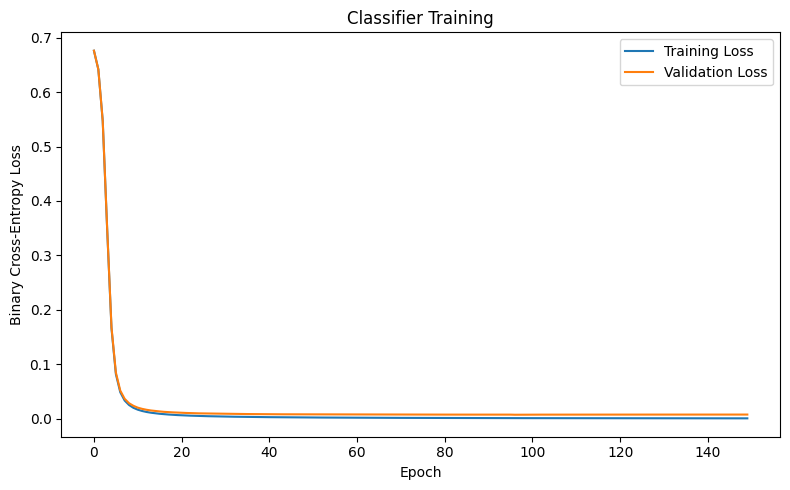

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Classifier Training')
plt.legend()
plt.tight_layout()
plt.show()

## Validation accuracy

In [8]:
y_pred = classifier.predict(X_val)  # shape: (1, n_val)
y_pred_labels = (y_pred.flatten() >= 0.5).astype(int)
accuracy = np.mean(y_pred_labels == y_val)
print(f'Validation accuracy: {accuracy:.4f}')

Validation accuracy: 0.9968


## Loss function and hyperparameter choices

- **Binary cross-entropy loss:** This is a binary classification problem (binding site or not) so BCE is the standard choice. It works well with sigmoid output and penalizes confident wrong predictions more than MSE would.
- **Learning rate (0.01):** Started with 0.1 but the loss was a bit jumpy. 0.01 gave smoother convergence. Didn't go lower because training was already taking a bit.
- **Architecture (68-32-16-1):** Input is 68 (17bp * 4 from one-hot). I went with two hidden layers to give the network enough capacity to learn non-linear patterns in the binding motif. The 32->16 bottleneck helps it generalize without memorizing.
- **ReLU for hidden layers:** Standard choice for hidden layers, avoids vanishing gradient issues that sigmoid has in deeper networks.
- **Sigmoid for output:** Outputs a probability between 0 and 1 which is what we need for binary classification.
- **Batch size (32):** Small enough to add noise for regularization, large enough to be stable.
- **Epochs (150):** Watched the loss curve -- it was pretty flat by around 100-120 epochs so 150 gives some room.